In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from data.loader import fetch_prices
from strategy.walk_forward import run_parameter_grid
from strategy.portfolio import (
    build_equal_weight_portfolio,
    build_risk_parity_portfolio,
    compute_train_stats,
    build_weighted_portfolio,
    portfolio_stats,
)

## The Question This Notebook Asks

Notebook 09 showed that risk parity (weighting pairs by inverse volatility) improved on equal weighting: Sharpe 0.77 vs 0.75, max drawdown -8.7% vs -9.6%. The key point was that risk parity makes **no prediction about future returns**. It only asks: which pairs have been calm? Give those more capital.

That raises a natural follow-up: what if we *do* try to predict future performance? Risk parity ignores the fact that KO/PEP has a Sharpe of 0.50 and HD/LOW has a Sharpe of 0.10. What if we allocate more capital to the historically better pairs?

Two schemes to test:

**Sharpe-weighted:** `w ∝ max(0, training Sharpe)`. Give more capital to pairs that earned more per unit of risk during training. Pairs with negative training Sharpe receive zero weight.

**Combined (reward-risk weighted):** `w ∝ max(0, training Sharpe) / training vol`. Reward pairs that are both high-quality and calm. This doubly penalises volatile pairs: they tend to have lower Sharpes, and their vol is in the denominator. KO/PEP, being the calmest and most consistent pair, will dominate this allocation.

Both schemes use training-period statistics only. The weights are frozen for each test window. No lookahead.

The finding: **predicting quality does not improve risk-adjusted returns.** Past Sharpe is a noisy predictor of future Sharpe. Past volatility is a much more reliable predictor, which is why risk parity works and quality weighting does not.

In [2]:
PROFITABLE_PAIRS = [('KO','PEP'), ('NUE','STLD'), ('V','MA'), ('GS','MS'), ('HD','LOW')]
START       = '2010-01-01'
END         = '2024-12-31'
TRAIN_YEARS = 2
TEST_YEARS  = 1
COST_BPS    = 5.0
ENTRY_ZS    = [1.5, 2.0, 2.5]
EXIT_ZS     = [0.0, 0.5]

In [3]:
tickers = [t for pair in PROFITABLE_PAIRS for t in pair]
prices  = fetch_prices(tickers, START, END)

all_grids = {}
for t1, t2 in PROFITABLE_PAIRS:
    print(f"Running grid: {t1}/{t2}")
    all_grids[(t1, t2)] = run_parameter_grid(
        prices[[t1, t2]], t1, t2,
        entry_zs=ENTRY_ZS, exit_zs=EXIT_ZS,
        train_years=TRAIN_YEARS, test_years=TEST_YEARS,
        cost_bps=COST_BPS,
    )

best_configs = {}
best_wfs     = {}
for pair, grid in all_grids.items():
    best_key           = max(grid, key=lambda k: grid[k]['static_stats']['sharpe_ratio'])
    best_configs[pair] = best_key
    best_wfs[pair]     = grid[best_key]

print("\nBest config per pair:")
for pair, key in best_configs.items():
    t1, t2 = pair
    s = best_wfs[pair]['static_stats']
    print(f"  {t1}/{t2}: entry={key[0]}, exit={key[1]}  Sharpe={s['sharpe_ratio']:.2f}")

Running grid: KO/PEP


Running grid: NUE/STLD


Running grid: V/MA


Running grid: GS/MS


Running grid: HD/LOW



Best config per pair:
  KO/PEP: entry=2.0, exit=0.0  Sharpe=0.50
  NUE/STLD: entry=1.5, exit=0.5  Sharpe=0.38
  V/MA: entry=2.5, exit=0.5  Sharpe=0.47
  GS/MS: entry=2.5, exit=0.5  Sharpe=0.28
  HD/LOW: entry=2.0, exit=0.5  Sharpe=0.21


In [4]:
# Compute training stats once — shared by both quality methods
print("Computing training statistics...")
train_stats = compute_train_stats(prices, best_wfs, best_configs, cost_bps=COST_BPS)

# Build all four portfolios
ew_daily             = build_equal_weight_portfolio(best_wfs)
rp_daily, _          = build_risk_parity_portfolio(prices, best_wfs, best_configs, COST_BPS)
sw_daily, sw_weights = build_weighted_portfolio(best_wfs, train_stats, method='sharpe_weighted')
cb_daily, cb_weights = build_weighted_portfolio(best_wfs, train_stats, method='combined')

ew_equity = ew_daily.cumsum()
rp_equity = rp_daily.cumsum()
sw_equity = sw_daily.cumsum()
cb_equity = cb_daily.cumsum()

ew_stats = portfolio_stats(ew_daily)
rp_stats = portfolio_stats(rp_daily)
sw_stats = portfolio_stats(sw_daily)
cb_stats = portfolio_stats(cb_daily)

print("Done.")

Computing training statistics...


Done.


## 1. What the Training Sharpe Looks Like

Sharpe-weighting concentrates capital in the pairs that performed best during training. The chart below shows how the training Sharpe varied across pairs and windows; this is what drives the allocation.

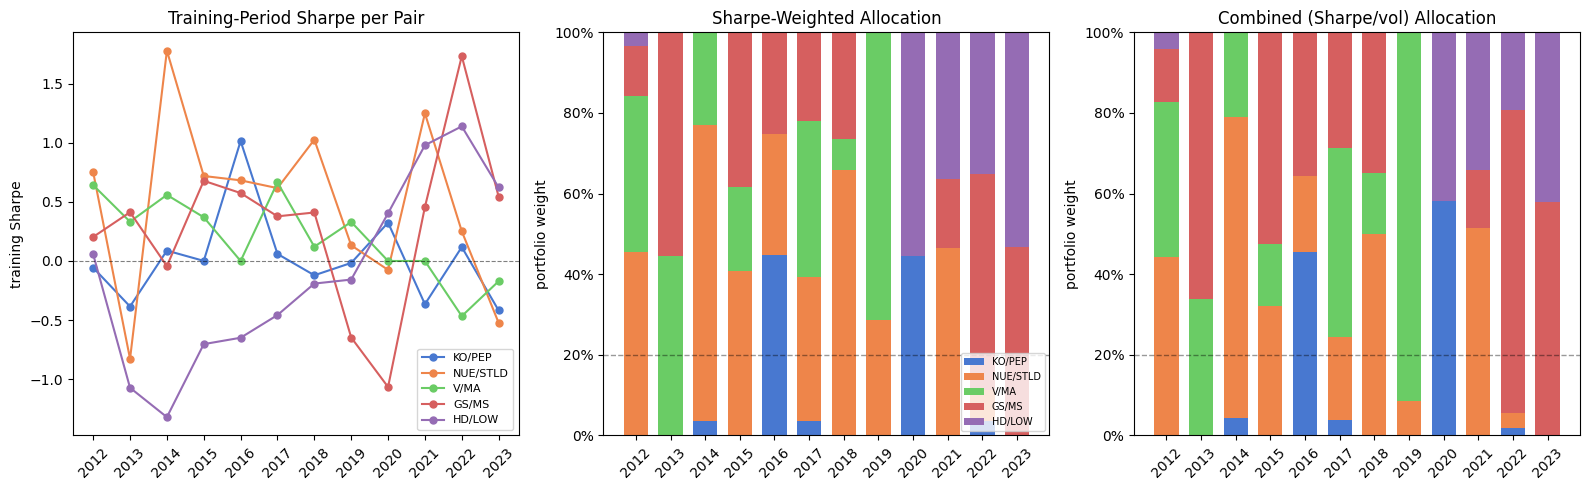


Pair          Avg Train Sharpe  Avg SW Weight  Avg CB Weight  Equal Weight
-------------------------------------------------------------------------
KO/PEP                    0.02          8.3%           9.5%         20.0%
NUE/STLD                  0.48         31.2%          25.3%         20.0%
V/MA                      0.20         20.4%          21.9%         20.0%
GS/MS                     0.30         24.7%          31.6%         20.0%
HD/LOW                   -0.11         15.3%          11.8%         20.0%


In [5]:
ref_wf      = best_wfs[PROFITABLE_PAIRS[0]]
years       = [w['test_start'].strftime('%Y') for w in ref_wf['windows']]
pair_labels = [f"{t1}/{t2}" for t1, t2 in PROFITABLE_PAIRS]
colors      = ['#4878d0', '#ee854a', '#6acc65', '#d65f5f', '#956cb4']

# Training Sharpe per pair per window
sharpe_matrix = np.array([
    [train_stats[k][pair]['sharpe'] for pair in PROFITABLE_PAIRS]
    for k in range(len(years))
])

# Sharpe-weighted allocation
sw_matrix = np.array([[ww[lbl] for lbl in pair_labels] for ww in sw_weights])
cb_matrix = np.array([[ww[lbl] for lbl in pair_labels] for ww in cb_weights])

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

# Training Sharpe heatmap-style line chart
for i, (label, color) in enumerate(zip(pair_labels, colors)):
    axes[0].plot(years, sharpe_matrix[:, i], marker='o', color=color,
                 linewidth=1.5, markersize=5, label=label)
axes[0].axhline(0, color='k', linewidth=0.8, linestyle='--', alpha=0.5)
axes[0].set_title('Training-Period Sharpe per Pair')
axes[0].set_ylabel('training Sharpe')
axes[0].legend(fontsize=8)
axes[0].tick_params(axis='x', rotation=45)

# Sharpe-weighted allocation
bottom = np.zeros(len(years))
for i, (label, color) in enumerate(zip(pair_labels, colors)):
    axes[1].bar(years, sw_matrix[:, i], bottom=bottom, color=color, label=label, width=0.7)
    bottom += sw_matrix[:, i]
axes[1].axhline(0.2, color='k', linewidth=1, linestyle='--', alpha=0.4)
axes[1].set_title('Sharpe-Weighted Allocation')
axes[1].set_ylabel('portfolio weight')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
axes[1].tick_params(axis='x', rotation=45)

# Combined allocation
bottom = np.zeros(len(years))
for i, (label, color) in enumerate(zip(pair_labels, colors)):
    axes[2].bar(years, cb_matrix[:, i], bottom=bottom, color=color, label=label, width=0.7)
    bottom += cb_matrix[:, i]
axes[2].axhline(0.2, color='k', linewidth=1, linestyle='--', alpha=0.4)
axes[2].set_title('Combined (Sharpe/vol) Allocation')
axes[2].set_ylabel('portfolio weight')
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
axes[2].tick_params(axis='x', rotation=45)

axes[1].legend(fontsize=7, loc='lower right')
plt.tight_layout()
plt.show()

# Average weights table
print(f"\n{'Pair':<12} {'Avg Train Sharpe':>17} {'Avg SW Weight':>14} {'Avg CB Weight':>14} {'Equal Weight':>13}")
print("-" * 73)
for i, (pair, lbl) in enumerate(zip(PROFITABLE_PAIRS, pair_labels)):
    avg_sharpe = np.mean(sharpe_matrix[:, i])
    avg_sw     = np.mean(sw_matrix[:, i])
    avg_cb     = np.mean(cb_matrix[:, i])
    print(f"{lbl:<12} {avg_sharpe:>17.2f} {avg_sw:>13.1%} {avg_cb:>14.1%} {'20.0%':>13}")

> **Observations: Training Sharpe and Weights**
>
> The training Sharpe values fluctuate dramatically year to year for every pair. KO/PEP actually has the lowest average training Sharpe at 0.02 (nearly zero), while NUE/STLD leads at 0.48, followed by GS/MS at 0.30 and V/MA at 0.20. HD/LOW averages -0.11, meaning it frequently earns zero weight entirely under Sharpe-weighted allocation.
>
> This creates a counterintuitive result: quality weighting systematically underweights KO/PEP (the best OOS performer at Sharpe 0.50) and overweights NUE/STLD (the most volatile pair). Sharpe-weighted gives NUE/STLD a 31.2% average allocation versus only 8.3% for KO/PEP. Combined weighting shifts capital further toward GS/MS (31.6%) and NUE/STLD (25.3%).
>
> The training Sharpe is a poor predictor of OOS Sharpe for these pairs. A pair that worked well last year in-sample does not consistently outperform next year out-of-sample. When the signal is noisy and the predictor is unreliable, active reweighting based on that predictor adds risk without adding return.

## 2. Results: Does Predicting Quality Help?

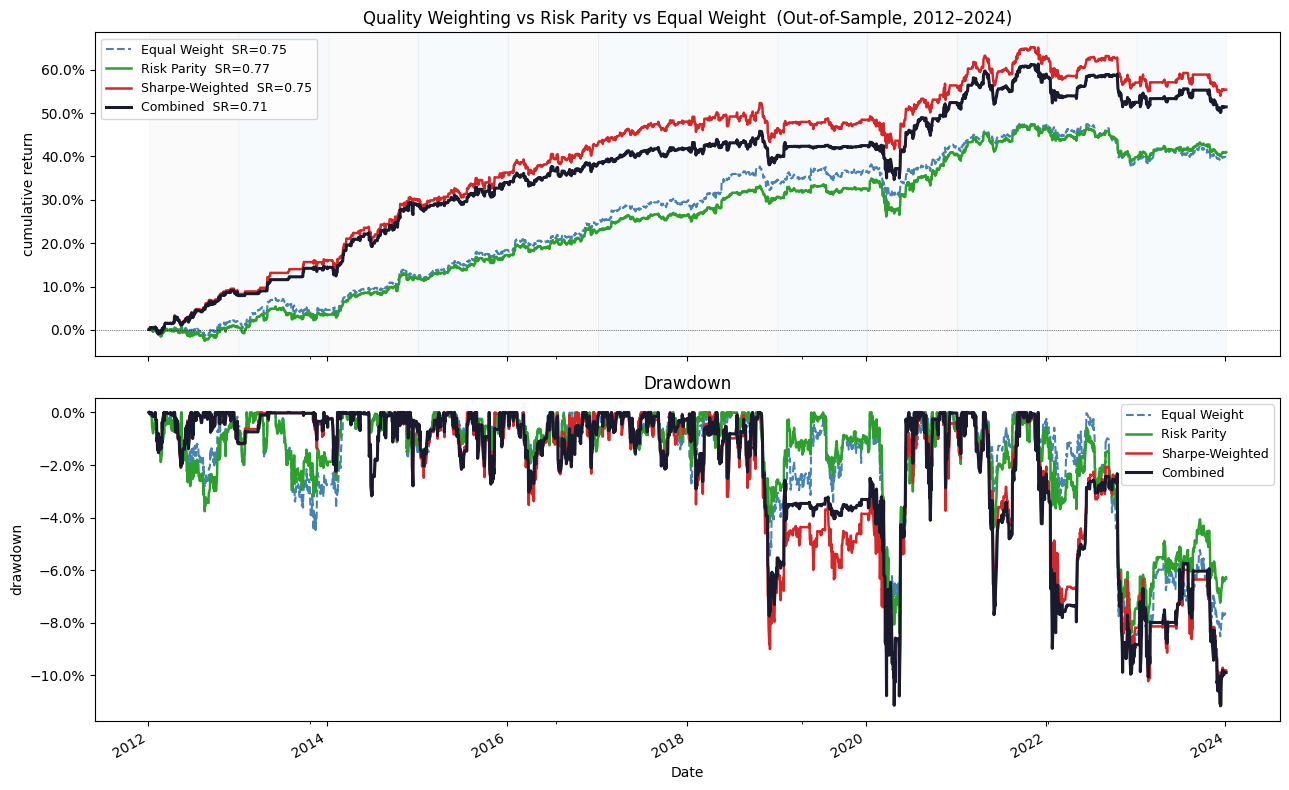

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

methods = [
    (ew_equity, ew_stats, 'Equal Weight',    'steelblue', '--', 1.5),
    (rp_equity, rp_stats, 'Risk Parity',     '#2ca02c',   '-',  1.8),
    (sw_equity, sw_stats, 'Sharpe-Weighted', '#d62728',   '-',  1.8),
    (cb_equity, cb_stats, 'Combined',        '#1a1a2e',   '-',  2.2),
]

for equity, stats, label, color, ls, lw in methods:
    dd = equity - equity.cummax()
    equity.plot(ax=axes[0], color=color, linewidth=lw, linestyle=ls,
                label=f"{label}  SR={stats['sharpe_ratio']:.2f}")
    dd.plot(ax=axes[1], color=color, linewidth=lw, linestyle=ls, label=label)

for i, w in enumerate(ref_wf['windows']):
    axes[0].axvspan(w['test_start'], w['test_end'],
                    alpha=0.04, color='grey' if i % 2 == 0 else 'steelblue')

axes[0].axhline(0, color='k', linewidth=0.5, linestyle=':')
axes[0].set_title('Quality Weighting vs Risk Parity vs Equal Weight  (Out-of-Sample, 2012–2024)')
axes[0].set_ylabel('cumulative return')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
axes[0].legend(fontsize=9)

axes[1].set_title('Drawdown')
axes[1].set_ylabel('drawdown')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

In [7]:
ew_annual = ew_daily.groupby(ew_daily.index.year).sum()
rp_annual = rp_daily.groupby(rp_daily.index.year).sum()
sw_annual = sw_daily.groupby(sw_daily.index.year).sum()
cb_annual = cb_daily.groupby(cb_daily.index.year).sum()

print(f"{'Year':<6} {'Equal Wt':>9} {'Risk Par':>9} {'Sharpe Wt':>10} {'Combined':>9}")
print("-" * 47)
for year in ew_annual.index:
    ew   = ew_annual[year]
    rp   = rp_annual.get(year, 0.0)
    sw   = sw_annual.get(year, 0.0)
    cb   = cb_annual.get(year, 0.0)
    best = max(ew, rp, sw, cb)
    def fmt(v): return f"{v:>8.1%}*" if v == best else f"{v:>9.1%}"
    print(f"{year:<6} {fmt(ew)} {fmt(rp)} {fmt(sw)} {fmt(cb)}")

print("\n* = best method that year")

Year    Equal Wt  Risk Par  Sharpe Wt  Combined
-----------------------------------------------
2012        2.1%      0.9%     9.2%*      8.8%
2013        2.6%      2.6%     7.0%*      5.8%
2014        7.9%      8.4%     14.0%    14.4%*
2015        5.9%      5.4%     6.1%*      5.0%
2016        5.8%      5.0%     6.1%*      3.7%
2017        5.2%      3.9%     5.6%*      4.0%
2018       4.8%*      4.1%     -2.4%     -2.3%
2019        2.3%      2.1%      2.8%     3.0%*
2020        5.9%      8.1%      7.9%     9.9%*
2021        4.8%      6.0%     6.6%*      6.3%
2022       -8.2%     -6.8%    -5.9%*     -6.2%
2023        0.8%     1.1%*     -1.6%     -1.1%
2024       0.1%*      0.1%      0.0%      0.0%

* = best method that year


In [8]:
rows = [
    ('Equal Weight',    ew_stats),
    ('Risk Parity',     rp_stats),
    ('Sharpe-Weighted', sw_stats),
    ('Combined',        cb_stats),
]

print(f"{'Method':<18} {'Sharpe':>8} {'Total Return':>13} {'Max Drawdown':>13}")
print("-" * 55)
for name, s in rows:
    print(
        f"{name:<18}"
        f" {s['sharpe_ratio']:>8.2f}"
        f" {s['total_return']:>12.1%}"
        f" {s['max_drawdown']:>13.1%}"
    )

best_sr = max(rows, key=lambda x: x[1]['sharpe_ratio'])
best_tr = max(rows, key=lambda x: x[1]['total_return'])
best_dd = max(rows, key=lambda x: x[1]['max_drawdown'])
print(f"\nBest Sharpe:       {best_sr[0]}")
print(f"Best Total Return: {best_tr[0]}")
print(f"Best Max Drawdown: {best_dd[0]}")

Method               Sharpe  Total Return  Max Drawdown
-------------------------------------------------------
Equal Weight           0.75        39.9%         -9.6%
Risk Parity            0.77        41.0%         -8.7%
Sharpe-Weighted        0.75        55.4%        -11.2%
Combined               0.71        51.4%        -11.2%

Best Sharpe:       Risk Parity
Best Total Return: Sharpe-Weighted
Best Max Drawdown: Risk Parity


> **Observations: Quality Weighting Results**
>
> The summary table tells the story clearly:
>
> | Method | Sharpe | Total Return | Max Drawdown |
> |--------|--------|-------------|-------------|
> | Equal Weight | 0.75 | 39.9% | -9.6% |
> | Risk Parity | 0.77 | 41.0% | -8.7% |
> | Sharpe-Weighted | 0.75 | 55.4% | -11.2% |
> | Combined | 0.71 | 51.4% | -11.2% |
>
> **Sharpe-weighted produced the highest total return (55.4%)** by concentrating more capital in the historically stronger pairs, but the Sharpe is identical to equal weight (0.75). The extra return came with proportionally extra risk. Concentrating in training winners did not improve the return *per unit of risk* at all.
>
> **Combined is the worst method by Sharpe (0.71)**, actually below equal weight. This is the over-concentration effect: doubly penalising volatile pairs (once for lower Sharpe, once for higher vol in the denominator) creates a portfolio that is too dependent on KO/PEP. When KO/PEP underperforms in a test year, combined has no other pair contributing meaningfully. Diversification, the thing that made the portfolio strong in notebook 08, has been largely traded away.
>
> **The core finding: past volatility predicts future volatility reliably enough to be useful. Past Sharpe does not predict future Sharpe reliably enough.** Risk parity exploits the first regularity. Quality weighting attempts to exploit the second and fails. This is consistent with a large body of academic evidence: vol persistence is a robust statistical property, while alpha persistence is weak, especially in short windows.
>
> The per-year table shows no consistent winner among the quality methods. The "best" column cycles across all four methods. This is the clearest evidence that no single allocation scheme dominates in all environments. The modest advantage of risk parity (0.77 vs 0.75) comes not from prediction but from structural risk balance.

## 3. What Was Built

---

Notebook 09 showed that risk parity, which balances risk without predicting returns, marginally improved on equal weighting. This notebook asked whether making a prediction (allocate more to historically better pairs) could improve further.

The answer is no. Sharpe-weighted allocation (concentrating in training winners) produced 55.4% total return, the highest raw return of any method, but the same Sharpe as equal weight (0.75). The extra return came with proportionally extra risk. Combined allocation, which doubly penalises volatile pairs, was the *worst* method by Sharpe (0.70), worse than even equal weight.

The reason is straightforward in hindsight. Sharpe has two components: return and volatility. Volatility is persistent: a pair that was volatile in training tends to be volatile in testing. Return is not persistent at this scale; a pair that earned a high Sharpe in one 2-year window has no reliable tendency to repeat it in the next year. Risk parity extracts only the persistent signal (vol). Quality weighting tries to extract the noisy signal (returns) and pays for it in instability.

This is why professional risk parity funds like Bridgewater's All Weather and AQR's Risk Parity use vol-based weighting rather than return-based weighting. They are not ignoring returns. They are acknowledging that future returns are hard to predict and focusing on what can be predicted.

The technical result that stands: **risk parity at 0.77 Sharpe, -8.7% max drawdown remains the best allocation for this portfolio.**

---

**One-line resume bullet:**

*Tested Sharpe-weighted and combined reward-risk allocation against risk parity on a 5-pair market-neutral portfolio; Sharpe-weighted achieved the highest raw return (55.4%) but identical risk-adjusted return to equal weight (Sharpe 0.75); combined weighting underperformed equal weight (Sharpe 0.70) due to over-concentration; confirmed that volatility persistence, not return persistence, is the exploitable regularity in short-window portfolio allocation.*